# Classification Conditional Encoder Confusion Matrcies

## Packages

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os
from pathlib import Path

## Functions

In [3]:
def response_to_epa_class(response_value):
    """Convert Response value to EPA toxicity class"""
    if response_value <= 50:
        return 1  # EPA Level 1
    elif response_value <= 500:
        return 2  # EPA Level 2
    elif response_value <= 5000:
        return 3  # EPA Level 3
    else:
        return 4  # EPA Level 4

def load_classification_outputs(base_folder, bin_val, threshold_val, use_super_test=False):
    """
    Load classification outputs from the saved folder structure
    """
    # Construct folder path - the outputs are in cond_enc_1234e1e2_classification_df6
    folder_name = "cond_enc_1234e1e2_classification_df6"
    folder_path = os.path.join(base_folder, folder_name)
    
    # Convert bin_val and threshold_val to the naming format (replace . with _)
    bin_part = str(bin_val).replace('.', '_')
    threshold_part = str(threshold_val).replace('.', '_')
    
    # Choose file name pattern based on use_super_test parameter
    if use_super_test:
        filename = f"super_test_cond_enc_bin{bin_part}_thresh{threshold_part}_df_spectra.parquet"
    else:
        filename = f"cond_enc_bin{bin_part}_thresh{threshold_part}_df_spectra.parquet"
    
    outputs_file = os.path.join(folder_path, filename)
    
    if not os.path.exists(outputs_file):
        raise FileNotFoundError(f"Output file not found: {outputs_file}")
    
    df = pd.read_parquet(outputs_file)
    
    # Add EPA class from Response values
    df['EPA_class'] = df['Response'].apply(response_to_epa_class)
    
    return df

def create_confusion_matrix_plot(y_true, y_pred, class_labels=None, title="Confusion Matrix", save_path=None):
    """
    Create and display a confusion matrix plot
    """
    # Create confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Set up class labels
    if class_labels is None:
        class_labels = [f"Class {i}" for i in range(len(np.unique(y_true)))]
    
    # Create the plot
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_labels, yticklabels=class_labels)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    
    return cm

def analyze_classification_results(base_folder, bin_val, threshold_val, use_super_test=False, save_plots=True):
    """
    Complete analysis function that loads outputs and creates confusion matrices
    """
    # Load the outputs
    try:
        df = load_classification_outputs(base_folder, bin_val, threshold_val, use_super_test)
        test_type = "Super Test" if use_super_test else "Regular Test"
        print(f"Loaded {test_type} outputs for bin={bin_val}, threshold={threshold_val}")
        print(f"Dataset shape: {df.shape}")
    except FileNotFoundError as e:
        print(f"Error: {e}")
        return None, None
    
    # Define EPA toxicity class labels
    epa_labels = ["EPA Level I", "EPA Level II", "EPA Level III", "EPA Level IV"]
    
    # Extract true and predicted labels
    y_true = df['EPA_class'].values  # EPA class derived from Response
    y_pred = df['cond_tox_pred_class'].values  # Predicted class
    
    print(f"Using EPA classes derived from Response values")
    
    # Since true labels are 1,2,3,4 and predicted are 0,1,2,3, we need to adjust
    print(f"True label distribution: {np.bincount(y_true, minlength=5)[1:]}")  # Skip index 0
    print(f"Predicted label distribution: {np.bincount(y_pred, minlength=4)}")
    
    # Convert true labels from 1,2,3,4 to 0,1,2,3 to match predictions
    y_true_adjusted = y_true - 1
    
    # Create confusion matrix
    test_label = "Super Test" if use_super_test else "Regular Test"
    cm = create_confusion_matrix_plot(
        y_true_adjusted, y_pred, 
        class_labels=epa_labels,
        title=f"Confusion Matrix - {test_label} (Bin={bin_val}, Threshold={threshold_val})",
        save_path=f"confusion_matrix_{'super_test_' if use_super_test else ''}bin{bin_val}_thr{threshold_val}.png" if save_plots else None
    )
    
    # Print classification report
    print("\nClassification Report:")
    print(classification_report(y_true_adjusted, y_pred, target_names=epa_labels))
    
    # Calculate and print accuracy metrics
    accuracy = np.sum(y_true_adjusted == y_pred) / len(y_true_adjusted)
    print(f"\nOverall Accuracy: {accuracy:.4f}")
    
    # Per-class accuracy
    print("\nPer-class Accuracy:")
    for i, label in enumerate(epa_labels):
        class_mask = y_true_adjusted == i
        if np.sum(class_mask) > 0:
            class_acc = np.sum((y_true_adjusted == y_pred) & class_mask) / np.sum(class_mask)
            print(f"{label}: {class_acc:.4f}")
    
    return df, cm

def compare_multiple_configurations(base_folder, bin_threshold_pairs, use_super_test=False, save_plots=True):
    """
    Compare results across multiple bin/threshold configurations
    """
    results = {}
    
    for bin_val, threshold_val in bin_threshold_pairs:
        print(f"\n{'='*50}")
        print(f"Analyzing Bin={bin_val}, Threshold={threshold_val}")
        print(f"{'='*50}")
        
        try:
            df, cm = analyze_classification_results(base_folder, bin_val, threshold_val, use_super_test, save_plots)
            if df is not None:
                y_true = df['EPA_class'].values - 1  # Convert from 1,2,3,4 to 0,1,2,3
                y_pred = df['cond_tox_pred_class'].values
                accuracy = np.sum(y_true == y_pred) / len(y_true)
                
                results[(bin_val, threshold_val)] = {
                    'accuracy': accuracy,
                    'confusion_matrix': cm,
                    'dataframe': df
                }
                
        except Exception as e:
            print(f"Error processing bin={bin_val}, threshold={threshold_val}: {e}")
    
    # Summary comparison
    if results:
        print(f"\n{'='*60}")
        print("SUMMARY COMPARISON")
        print(f"{'='*60}")
        print(f"{'Bin':<8} {'Threshold':<12} {'Accuracy':<10}")
        print("-" * 30)
        
        for (bin_val, threshold_val), metrics in results.items():
            print(f"{bin_val:<8} {threshold_val:<12} {metrics['accuracy']:.4f}")
    
    return results

def visualize_classification(folder, bin_size, threshold_size, use_super_test=False, save_plots=True):
    """
    Main visualization function that takes folder, bin size, and threshold size
    
    Parameters:
    folder (str): Base folder path containing the classification outputs
    bin_size (int/float): Bin size value
    threshold_size (float): Threshold size value  
    use_super_test (bool): Whether to load super test results or regular test results
    save_plots (bool): Whether to save plots as PNG files
    
    Returns:
    tuple: DataFrame and confusion matrix from the analysis
    """
    test_type = "Super Test" if use_super_test else "Regular Test"
    print(f"Analyzing {test_type} classification results:")
    print(f"Folder: {folder}")
    print(f"Bin size: {bin_size}")
    print(f"Threshold size: {threshold_size}")
    print("-" * 50)
    
    # Run the analysis
    df, cm = analyze_classification_results(folder, bin_size, threshold_size, use_super_test, save_plots)
    
    return df, cm

## Confusion Matrix

Analyzing Regular Test classification results:
Folder: /home/dlipsey/MITLincolnLabs/MIT_LL_data/
Bin size: 1
Threshold size: 0.05
--------------------------------------------------
Loaded Regular Test outputs for bin=1, threshold=0.05
Dataset shape: (14697, 4618)
Using EPA classes derived from Response values
True label distribution: [ 738 3444 8114 2401]
Predicted label distribution: [ 742 3335 8186 2434]


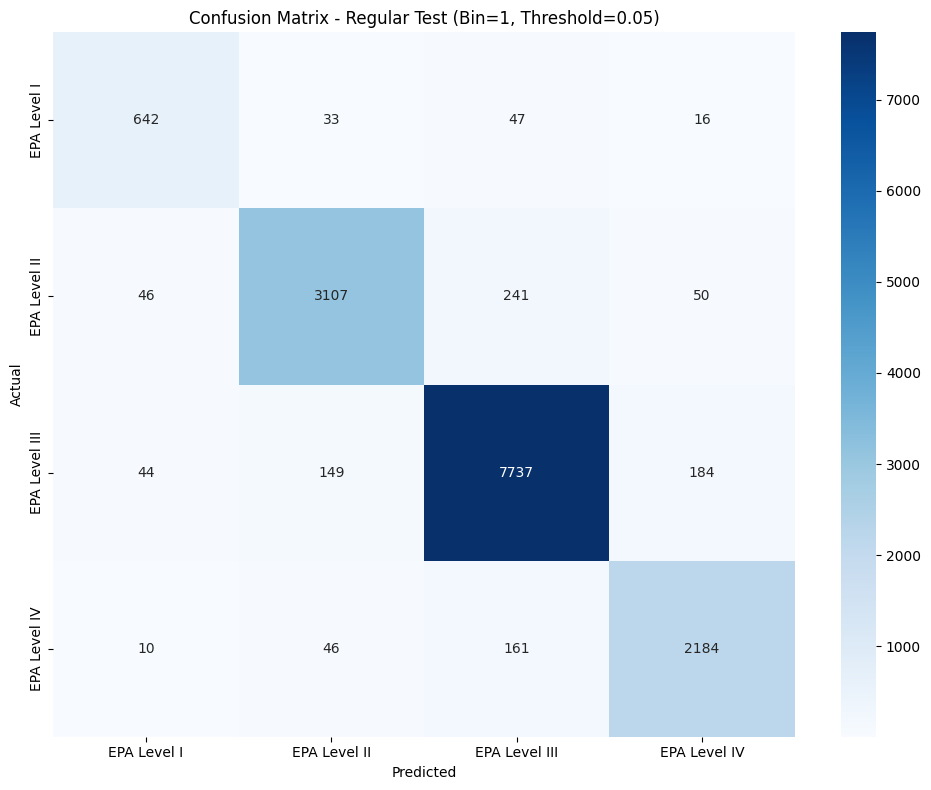


Classification Report:
               precision    recall  f1-score   support

  EPA Level I       0.87      0.87      0.87       738
 EPA Level II       0.93      0.90      0.92      3444
EPA Level III       0.95      0.95      0.95      8114
 EPA Level IV       0.90      0.91      0.90      2401

     accuracy                           0.93     14697
    macro avg       0.91      0.91      0.91     14697
 weighted avg       0.93      0.93      0.93     14697


Overall Accuracy: 0.9301

Per-class Accuracy:
EPA Level I: 0.8699
EPA Level II: 0.9021
EPA Level III: 0.9535
EPA Level IV: 0.9096


In [ ]:
# Example execution - generates confusion matrix with heatmap visualization
df, cm = visualize_classification(
    folder="/home/dlipsey/MITLincolnLabs/MIT_LL_data/",
    bin_size=1,
    threshold_size=0.05,
    use_super_test=False,
    save_plots=False
)

## Looking at the output dataframe

In [5]:
# Check what columns are actually in the output file
import pandas as pd

# Load one of the output files to see column structure
test_file = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/cond_enc_1234e1e2_classification_df6/cond_enc_bin0_5_thresh0_05_df_spectra.parquet"
df_sample = pd.read_parquet(test_file)

print("Dataset shape:", df_sample.shape)
print("\nColumn names:")
print(df_sample.columns.tolist())
print("\nDataFrame head:")
df_sample.head()

Dataset shape: (14697, 4617)

Column names:
['cond_emb_0', 'cond_emb_1', 'cond_emb_2', 'cond_emb_3', 'cond_emb_4', 'cond_emb_5', 'cond_emb_6', 'cond_emb_7', 'cond_emb_8', 'cond_emb_9', 'cond_emb_10', 'cond_emb_11', 'cond_emb_12', 'cond_emb_13', 'cond_emb_14', 'cond_emb_15', 'cond_emb_16', 'cond_emb_17', 'cond_emb_18', 'cond_emb_19', 'cond_emb_20', 'cond_emb_21', 'cond_emb_22', 'cond_emb_23', 'cond_emb_24', 'cond_emb_25', 'cond_emb_26', 'cond_emb_27', 'cond_emb_28', 'cond_emb_29', 'cond_emb_30', 'cond_emb_31', 'cond_emb_32', 'cond_emb_33', 'cond_emb_34', 'cond_emb_35', 'cond_emb_36', 'cond_emb_37', 'cond_emb_38', 'cond_emb_39', 'cond_emb_40', 'cond_emb_41', 'cond_emb_42', 'cond_emb_43', 'cond_emb_44', 'cond_emb_45', 'cond_emb_46', 'cond_emb_47', 'cond_emb_48', 'cond_emb_49', 'cond_emb_50', 'cond_emb_51', 'cond_emb_52', 'cond_emb_53', 'cond_emb_54', 'cond_emb_55', 'cond_emb_56', 'cond_emb_57', 'cond_emb_58', 'cond_emb_59', 'cond_emb_60', 'cond_emb_61', 'cond_emb_62', 'cond_emb_63', 'cond

,cond_emb_0,cond_emb_1,cond_emb_2,cond_emb_3,cond_emb_4,cond_emb_5,cond_emb_6,cond_emb_7,cond_emb_8,cond_emb_9,...,cond_filtered_morgan_2042,cond_filtered_morgan_2043,cond_filtered_morgan_2044,cond_filtered_morgan_2045,cond_filtered_morgan_2046,cond_filtered_morgan_2047,SMILES_spectra,Response,log_response,index_id
0,0.426019,0.009262,-0.415676,-0.056550,-0.066936,0.010116,0.114865,-0.479440,-0.065906,-0.038235,...,0.039694,0.005954,-0.025594,-0.018323,-0.015757,-0.018616,C#CC(C)(C)NC(=O)c1cc(Cl)cc(Cl)c1,3335.479075,8.112372,0
1,0.409292,0.013064,-0.431695,-0.079572,-0.086733,0.011185,0.160120,-0.465561,-0.069937,-0.005491,...,0.039679,0.012029,-0.018676,-0.030425,-0.014413,-0.022754,C#CC(C)(C)NC(=O)c1cc(Cl)cc(Cl)c1,3335.479075,8.112372,1
2,0.146143,-0.000142,-0.294828,-0.233298,-0.201873,0.054636,0.046170,-0.236208,-0.145859,0.110730,...,0.008283,0.006447,-0.006872,-0.035553,-0.002607,-0.004178,C#CC(C)(C)NC(=O)c1cc(Cl)cc(Cl)c1,3335.479075,8.112372,2
3,0.377708,0.021777,-0.463569,-0.060977,-0.094463,-0.002483,-0.013831,-0.447614,-0.010933,-0.116878,...,0.026119,-0.013028,-0.007113,0.024194,0.005132,-0.027031,C#CC(C)(C)NC(=O)c1cc(Cl)cc(Cl)c1,3335.479075,8.112372,3
4,0.454595,0.004390,-0.576694,-0.063135,-0.114924,0.003574,0.020413,-0.567155,0.025930,-0.095527,...,0.020215,-0.024616,-0.023845,0.075216,-0.002970,-0.032647,C#CC(C)(C)NC(=O)c1cc(Cl)cc(Cl)c1,3335.479075,8.112372,4


In [6]:
print(df_sample['cond_tox_pred_class'].value_counts())

cond_tox_pred_class
2    8232
1    3341
3    2404
0     720
Name: count, dtype: int64


## Percent Confusion Matrix

Plot saved as: confusion_matrix_percentages_bin0.5_thr0.05.png


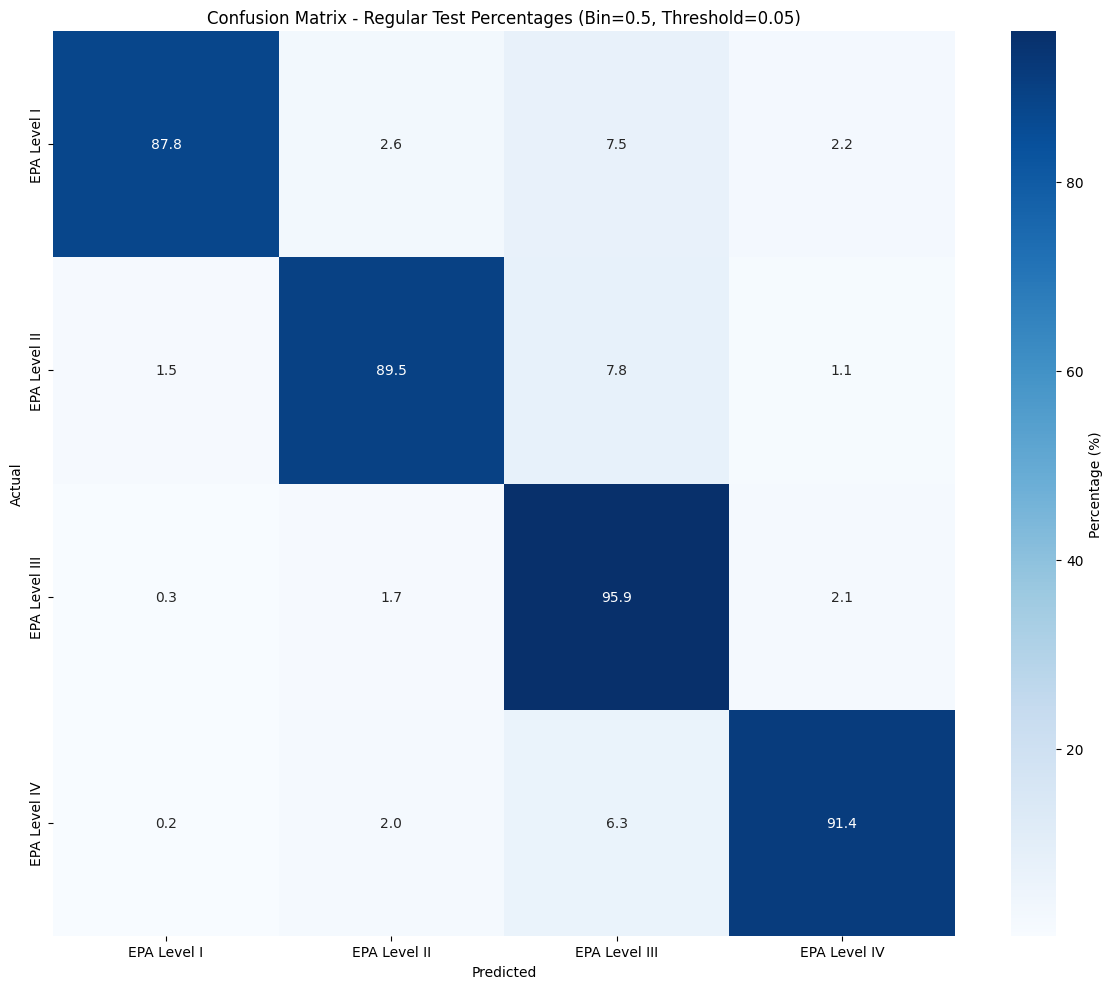


Percentage breakdown by actual label (Bin=0.5, Threshold=0.05):

EPA Level I (Total: 738 samples):
  → EPA Level I: 87.8% (648/738 samples)
  → EPA Level II: 2.6% (19/738 samples)
  → EPA Level III: 7.5% (55/738 samples)
  → EPA Level IV: 2.2% (16/738 samples)

EPA Level II (Total: 3444 samples):
  → EPA Level I: 1.5% (52/3444 samples)
  → EPA Level II: 89.5% (3084/3444 samples)
  → EPA Level III: 7.8% (269/3444 samples)
  → EPA Level IV: 1.1% (39/3444 samples)

EPA Level III (Total: 8114 samples):
  → EPA Level I: 0.3% (27/8114 samples)
  → EPA Level II: 1.7% (139/8114 samples)
  → EPA Level III: 95.9% (7780/8114 samples)
  → EPA Level IV: 2.1% (168/8114 samples)

EPA Level IV (Total: 2401 samples):
  → EPA Level I: 0.2% (6/2401 samples)
  → EPA Level II: 2.0% (49/2401 samples)
  → EPA Level III: 6.3% (152/2401 samples)
  → EPA Level IV: 91.4% (2194/2401 samples)


In [ ]:
# Create percentage-based confusion matrix heatmap
def create_percentage_confusion_matrix_standalone(folder, bin_size, threshold_size, use_super_test=False, save_plots=True):
    """
    Standalone function to create percentage confusion matrix from classification outputs
    Each row shows how the actual label was distributed across predictions
    """
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import confusion_matrix
    import os
    
    def response_to_epa_class_local(response_value):
        """Convert Response value to EPA toxicity class"""
        if response_value <= 50:
            return 1  # EPA Level 1
        elif response_value <= 500:
            return 2  # EPA Level 2
        elif response_value <= 5000:
            return 3  # EPA Level 3
        else:
            return 4  # EPA Level 4
    
    # Load the classification outputs
    folder_name = "cond_enc_1234e1e2_classification_df6"
    folder_path = os.path.join(folder, folder_name)
    
    # Convert bin_size and threshold_size to the naming format (replace . with _)
    bin_part = str(bin_size).replace('.', '_')
    threshold_part = str(threshold_size).replace('.', '_')
    
    # Choose file name pattern based on use_super_test parameter
    if use_super_test:
        filename = f"super_test_cond_enc_bin{bin_part}_thresh{threshold_part}_df_spectra.parquet"
    else:
        filename = f"cond_enc_bin{bin_part}_thresh{threshold_part}_df_spectra.parquet"
    
    outputs_file = os.path.join(folder_path, filename)
    
    if not os.path.exists(outputs_file):
        raise FileNotFoundError(f"Output file not found: {outputs_file}")
    
    df = pd.read_parquet(outputs_file)
    
    # Add EPA class from Response values
    df['EPA_class'] = df['Response'].apply(response_to_epa_class_local)
    
    # Extract and adjust labels
    y_true = df['EPA_class'].values - 1  # Convert from 1,2,3,4 to 0,1,2,3
    y_pred = df['cond_tox_pred_class'].values
    
    # Define EPA labels
    class_labels = ["EPA Level I", "EPA Level II", "EPA Level III", "EPA Level IV"]
    
    # Create confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Convert to percentages (row-wise normalization)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    # Create the plot
    plt.figure(figsize=(12, 10))
    
    # Create heatmap with percentage values
    sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues', 
                xticklabels=class_labels, yticklabels=class_labels,
                cbar_kws={'label': 'Percentage (%)'})
    
    test_type = "Super Test" if use_super_test else "Regular Test"
    plt.title(f"Confusion Matrix - {test_type} Percentages (Bin={bin_size}, Threshold={threshold_size})")
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    
    if save_plots:
        save_path = f"confusion_matrix_percentages_{'super_test_' if use_super_test else ''}bin{bin_size}_thr{threshold_size}.png"
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved as: {save_path}")
    
    plt.show()
    
    # Print percentage breakdown with proportions
    print(f"\nPercentage breakdown by actual label (Bin={bin_size}, Threshold={threshold_size}):")
    for i, actual_label in enumerate(class_labels):
        row_total = cm.sum(axis=1)[i]
        print(f"\n{actual_label} (Total: {row_total} samples):")
        for j, pred_label in enumerate(class_labels):
            count = cm[i, j]
            percentage = cm_percent[i, j]
            print(f"  → {pred_label}: {percentage:.1f}% ({count}/{row_total} samples)")
    
    return cm_percent, df

# Execute the function - modify bin_size and threshold_size as needed
cm_percent, df_analysis = create_percentage_confusion_matrix_standalone(
    folder="/home/dlipsey/MITLincolnLabs/MIT_LL_data/",
    bin_size=0.5,
    threshold_size=0.05,
    use_super_test=False,
    save_plots=False
)

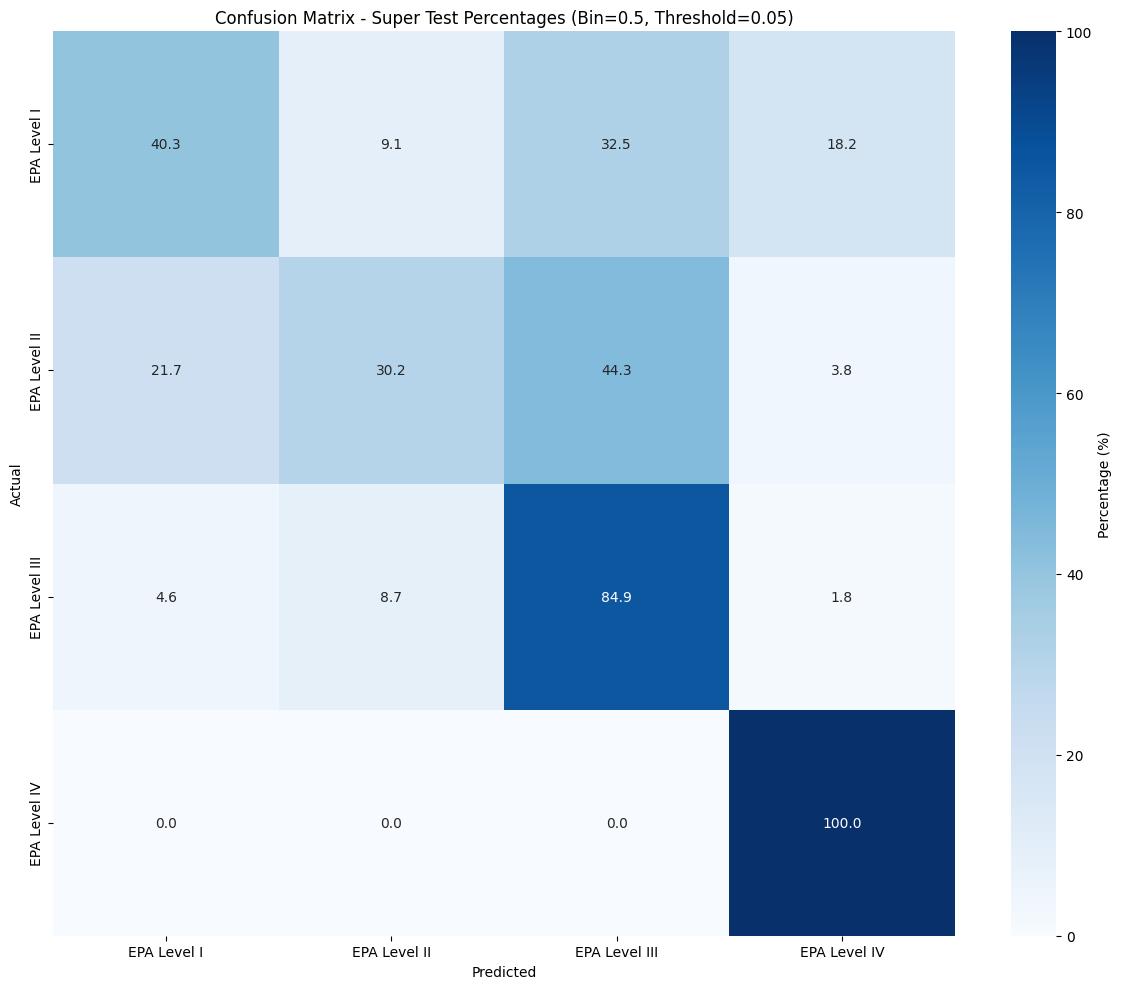


Percentage breakdown by actual label (Bin=0.5, Threshold=0.05):

EPA Level I (Total: 77 samples):
  → EPA Level I: 40.3% (31/77 samples)
  → EPA Level II: 9.1% (7/77 samples)
  → EPA Level III: 32.5% (25/77 samples)
  → EPA Level IV: 18.2% (14/77 samples)

EPA Level II (Total: 106 samples):
  → EPA Level I: 21.7% (23/106 samples)
  → EPA Level II: 30.2% (32/106 samples)
  → EPA Level III: 44.3% (47/106 samples)
  → EPA Level IV: 3.8% (4/106 samples)

EPA Level III (Total: 218 samples):
  → EPA Level I: 4.6% (10/218 samples)
  → EPA Level II: 8.7% (19/218 samples)
  → EPA Level III: 84.9% (185/218 samples)
  → EPA Level IV: 1.8% (4/218 samples)

EPA Level IV (Total: 6 samples):
  → EPA Level I: 0.0% (0/6 samples)
  → EPA Level II: 0.0% (0/6 samples)
  → EPA Level III: 0.0% (0/6 samples)
  → EPA Level IV: 100.0% (6/6 samples)


In [2]:
# Create percentage-based confusion matrix heatmap
def create_percentage_confusion_matrix_standalone(folder, bin_size, threshold_size, use_super_test=False, save_plots=True):
    """
    Standalone function to create percentage confusion matrix from classification outputs
    Each row shows how the actual label was distributed across predictions
    """
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import confusion_matrix
    import os
    
    def response_to_epa_class_local(response_value):
        """Convert Response value to EPA toxicity class"""
        if response_value <= 50:
            return 1  # EPA Level 1
        elif response_value <= 500:
            return 2  # EPA Level 2
        elif response_value <= 5000:
            return 3  # EPA Level 3
        else:
            return 4  # EPA Level 4
    
    # Load the classification outputs
    folder_name = "cond_enc_1234e1e2_classification_df6_super_test"
    folder_path = os.path.join(folder, folder_name)
    
    # Convert bin_size and threshold_size to the naming format (replace . with _)
    bin_part = str(bin_size).replace('.', '_')
    threshold_part = str(threshold_size).replace('.', '_')
    
    # Choose file name pattern based on use_super_test parameter
    if use_super_test:
        filename = f"super_test_cond_enc_bin{bin_part}_thresh{threshold_part}_df_spectra.parquet"
    else:
        filename = f"cond_enc_bin{bin_part}_thresh{threshold_part}_df_spectra.parquet"
    
    outputs_file = os.path.join(folder_path, filename)
    
    if not os.path.exists(outputs_file):
        raise FileNotFoundError(f"Output file not found: {outputs_file}")
    
    df = pd.read_parquet(outputs_file)
    
    # Add EPA class from Response values
    df['EPA_class'] = df['Response'].apply(response_to_epa_class_local)
    
    # Extract and adjust labels
    y_true = df['EPA_class'].values - 1  # Convert from 1,2,3,4 to 0,1,2,3
    y_pred = df['cond_tox_pred_class'].values
    
    # Define EPA labels
    class_labels = ["EPA Level I", "EPA Level II", "EPA Level III", "EPA Level IV"]
    
    # Create confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Convert to percentages (row-wise normalization)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    # Create the plot
    plt.figure(figsize=(12, 10))
    
    # Create heatmap with percentage values
    sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues', 
                xticklabels=class_labels, yticklabels=class_labels,
                cbar_kws={'label': 'Percentage (%)'})
    
    test_type = "Super Test" if use_super_test else "Regular Test"
    plt.title(f"Confusion Matrix - {test_type} Percentages (Bin={bin_size}, Threshold={threshold_size})")
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    
    if save_plots:
        save_path = f"confusion_matrix_percentages_{'super_test_' if use_super_test else ''}bin{bin_size}_thr{threshold_size}.png"
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved as: {save_path}")
    
    plt.show()
    
    # Print percentage breakdown with proportions
    print(f"\nPercentage breakdown by actual label (Bin={bin_size}, Threshold={threshold_size}):")
    for i, actual_label in enumerate(class_labels):
        row_total = cm.sum(axis=1)[i]
        print(f"\n{actual_label} (Total: {row_total} samples):")
        for j, pred_label in enumerate(class_labels):
            count = cm[i, j]
            percentage = cm_percent[i, j]
            print(f"  → {pred_label}: {percentage:.1f}% ({count}/{row_total} samples)")
    
    return cm_percent, df

# Execute the function - modify bin_size and threshold_size as needed
cm_percent, df_analysis = create_percentage_confusion_matrix_standalone(
    folder="/home/dlipsey/MITLincolnLabs/MIT_LL_data/",
    bin_size=0.5,
    threshold_size=0.05,
    use_super_test=True,
    save_plots=False
)